# AI Resume Screening and Candidate Fit Prediction

**Objective:** Prioritize resumes for human review using transparent NLP features rather than opaque keyword filtering.

This notebook uses deterministic demo text so the complete workflow runs without private or externally hosted data. Labels are used only for supervised training and evaluation.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo dataset


In [2]:
TOPICS = {
  "shortlist": [
    "python",
    "sql",
    "machine learning",
    "deployment",
    "experimentation",
    "stakeholder",
    "cloud",
    "analytics"
  ],
  "review": [
    "beginner",
    "coursework",
    "support",
    "documentation",
    "operations",
    "manual",
    "internship",
    "learning"
  ]
}
COMMON_WORDS = ["customer", "service", "today", "online", "request", "information", "please", "system"]
rows = []
for label, vocabulary in TOPICS.items():
    for row_id in range(180):
        signal = rng.choice(vocabulary, size=6, replace=True).tolist()
        context = rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        other_labels = [name for name in TOPICS if name != label]
        cross_noise = []
        if rng.random() < 0.35:
            other = rng.choice(other_labels)
            cross_noise = rng.choice(TOPICS[other], size=3, replace=True).tolist()
        tokens = signal + context + cross_noise
        rng.shuffle(tokens)
        observed_label = rng.choice(other_labels) if rng.random() < 0.08 else label
        rows.append({"resume_text": " ".join(tokens), "fit_decision": observed_label})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head())
display(data["fit_decision"].value_counts().rename("count").to_frame())


Dataset shape: 360 rows × 2 columns


,resume_text,fit_decision
0,manual experimentation manual operations reque...,review
1,stakeholder request request machine learning s...,shortlist
2,customer information beginner beginner interns...,review
3,documentation operations today manual document...,shortlist
4,sql analytics deployment please system experim...,shortlist


,count
fit_decision,
shortlist,182
review,178


## 3. Data quality and exploratory analysis


,dtype,missing,unique
resume_text,object,0,360
fit_decision,object,0,2


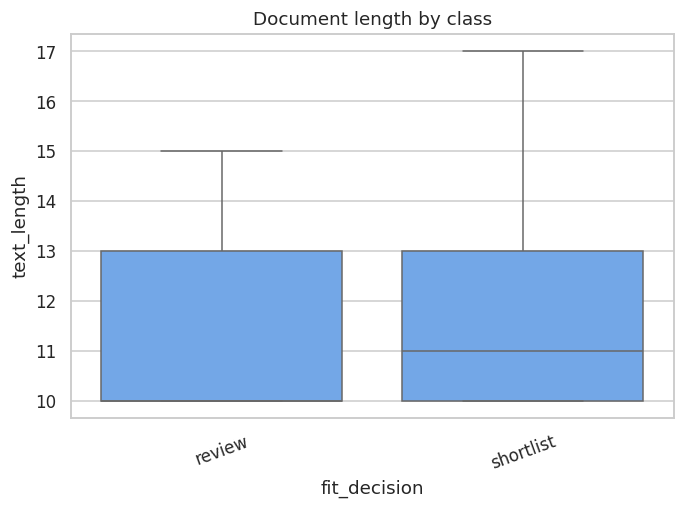

In [3]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
})
display(quality)
data["text_length"] = data["resume_text"].str.split().str.len()
sns.boxplot(data=data, x="fit_decision", y="text_length", color="#60a5fa")
plt.title("Document length by class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Leakage-safe split, baseline, and candidate models


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    data["resume_text"], data["fit_decision"], test_size=0.25,
    random_state=RANDOM_STATE, stratify=data["fit_decision"],
)
models = {
    "Majority baseline": Pipeline([("tfidf", TfidfVectorizer()), ("model", DummyClassifier(strategy="prior"))]),
    "Multinomial Naive Bayes": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("model", MultinomialNB(alpha=0.6))]),
    "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    comparison.append({"model": name, "cv_macro_f1": scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,model,cv_macro_f1,cv_std
0,Multinomial Naive Bayes,0.9109,0.0379
1,Logistic Regression,0.9072,0.0310
2,Majority baseline,0.3366,0.0040


## 5. Holdout evaluation


Selected model: Multinomial Naive Bayes
Holdout accuracy: 0.8889
Holdout macro F1: 0.8888


,precision,recall,f1-score,support
review,0.8723,0.9111,0.8913,45.0000
shortlist,0.9070,0.8667,0.8864,45.0000
accuracy,0.8889,0.8889,0.8889,0.8889
macro avg,0.8897,0.8889,0.8888,90.0000
weighted avg,0.8897,0.8889,0.8888,90.0000


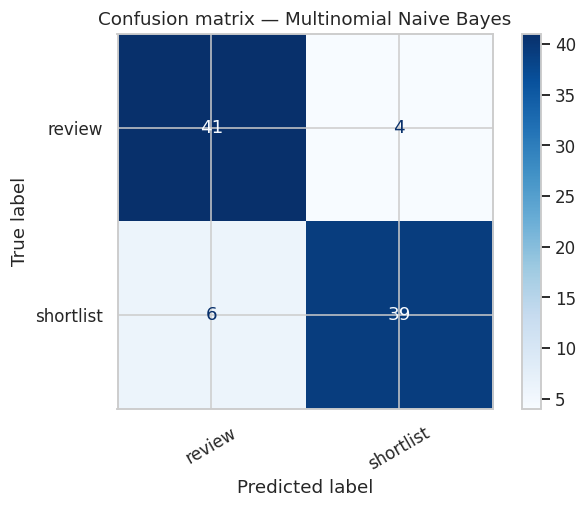

In [5]:
best_name = comparison.iloc[0]["model"]
best_model = models[best_name].fit(X_train, y_train)
predictions = best_model.predict(X_test)
print(f"Selected model: {best_name}")
print(f"Holdout accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Holdout macro F1: {f1_score(y_test, predictions, average='macro'):.4f}")
display(pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).T.round(4))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 6. Model interpretation and sample predictions


In [6]:
if best_name == "Logistic Regression":
    vectorizer = best_model.named_steps["tfidf"]
    classifier = best_model.named_steps["model"]
    terms = np.asarray(vectorizer.get_feature_names_out())
    rows = []
    coefficients = classifier.coef_ if len(classifier.classes_) > 2 else np.vstack([-classifier.coef_[0], classifier.coef_[0]])
    for class_name, weights in zip(classifier.classes_, coefficients):
        for term, weight in zip(terms[np.argsort(weights)[-8:]], np.sort(weights)[-8:]):
            rows.append({"class": class_name, "term": term, "weight": weight})
    display(pd.DataFrame(rows).sort_values(["class", "weight"], ascending=[True, False]).round(3))

sample = pd.DataFrame({"text": X_test.iloc[:8], "actual": y_test.iloc[:8], "predicted": predictions[:8]})
display(sample)


,text,actual,predicted
52,operations online operations internship course...,review,review
30,coursework manual customer please documentatio...,review,review
185,information deployment information stakeholder...,shortlist,shortlist
247,manual operations online please online coursew...,review,review
123,system sql machine learning please experimenta...,shortlist,shortlist
214,coursework operations python deployment online...,review,review
336,online cloud cloud experimentation please plea...,shortlist,shortlist
90,experimentation cloud cloud request experiment...,shortlist,shortlist


## 7. Responsible-use notes and next steps

- Replace deterministic demo text with versioned, licensed, representative data.
- Review class definitions, annotation quality, subgroup performance, and threshold costs with domain experts.
- Keep humans in the loop for hiring, moderation, security, healthcare, finance, and other consequential decisions.
- Monitor vocabulary drift and abstain when confidence or data quality is low.
